# **Nuclei segmentation using StarDist**

**After testing various min_percentile and max_percentile for image normalization, various number of PCs and resolution for clustering, various prob_thresh and nms_thresh for StarDist we set on final parameters that are used in this notebook.** Exploration in Visium HD slides.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import anndata
import geopandas as gpd
import scanpy as sc

from skimage.io import imread as imread_jpeg
from tifffile import imread as imread_tif
from tifffile import imwrite
from csbdeep.utils import normalize
from stardist.models import StarDist2D
from shapely.geometry import Polygon, Point
from scipy import sparse
from matplotlib.colors import ListedColormap

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

bioimageio_utils.py (2): pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.


## Data Paths

In [ ]:

################# Gene Expression Data ##############
# If loading EOM samples, refer to CSD_hpc/data/lab/spatial/ which was generated by Vincent Laville 
# If loading embryo head samples, refer to /pasteur/helix/projects/CSD_hpc/Naomie/visiumHD/visiumHD_outputs/ which was generated by Naomie

### EOM - Vincent results
#dir_base_exp=f"/pasteur/helix/projects/CSD_hpc/data/lab/spatial/EOM_VisiumHD/counts/Sample_D1/outs/binned_outputs/square_00{binning}um/"

### Embryo head - Naomie's outputs from spaceranger count ran on high resolution image after manual alignment with highres image
## A1
dir_base_exp="/pasteur/helix/projects/CSD_hpc/Naomie/visiumHD/visiumHD_outputs/embryo_head/counts/Sample_A1/outs/binned_outputs/square_002um/"
## D1
#dir_base_exp="/pasteur/helix/projects/CSD_hpc/Naomie/visiumHD/visiumHD_outputs/embryo_head/counts/Sample_D1/outs/binned_outputs/square_002um/"




################### Images #########################

## EOM
#dir_base = '/pasteur/helix/projects/CSD_hpc/data/lab/spatial/EOM_VisiumHD/scan_he/tiff_converted/'
#filename = 'sample_D1_highres_rgb.tif'


## embryo head
dir_base = '/pasteur/helix/projects/CSD_hpc/data/lab/spatial/embryo_head_VisiumHD/images/'
# A1
filename = 'A1_highres_RGB.tif'
# D1
#filename = 'D1_highres_RGB.tif'



### **Parameters to be set by the user**

In [2]:
## Parameters for the normalization of the image
min_percentile = 1
max_percentile = 99

## Parameters of the StarDist model
# Larger prob_thresh value will result in fewer segmented objects
# Smaller nms_thresh will reduce the probability of nuclei overlap
prob_thresh = 0.3
nms_thresh = 0.0001

binning = 2 


Data visualization helper function

In [3]:
# General image plotting functions
def plot_mask_and_save_image(title, gdf, img, cmap, output_name=None, bbox=None, buffer=15):
    if bbox is not None:
        # Crop the image to the bounding box
        cropped_img = img[bbox[1]:bbox[3], bbox[0]:bbox[2]]
    else:
        cropped_img = img

    # Plot options
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    # Plot the cropped image
    axes[0].imshow(cropped_img, cmap='gray', origin='lower')
    axes[0].set_title(title)
    axes[0].axis('off')

    # Create filtering polygon
    if bbox is not None:
        bbox_polygon = Polygon([(bbox[0], bbox[1]), (bbox[2], bbox[1]), (bbox[2], bbox[3]), (bbox[0], bbox[3])])
        # Filter for polygons in the box
        intersects_bbox = gdf['geometry'].intersects(bbox_polygon)
        filtered_gdf = gdf[intersects_bbox]
    else:
        filtered_gdf=gdf

    filtered_gdf['geometry'] = filtered_gdf['geometry'].buffer(buffer)
    # Plot the filtered polygons on the second axis
    filtered_gdf.plot(cmap=cmap, ax=axes[1])
    axes[1].axis('off')
    axes[1].legend(loc='upper left', bbox_to_anchor=(1.05, 1))


    # Save the plot if output_name is provided
    if output_name is not None:
        plt.savefig(output_name, bbox_inches='tight')  # Use bbox_inches='tight' to include the legend
    else:
        plt.show()

def plot_gene_and_save_image(title, gdf, gene, img, adata, bbox=None, output_name=None, buffer=15, cmap='viridis'):

    if bbox is not None:
        # Crop the image to the bounding box
        cropped_img = img[bbox[1]:bbox[3], bbox[0]:bbox[2]]
    else:
        cropped_img = img

    # Plot options
    fig, axes = plt.subplots(1, 2, figsize=(15, 9))

    # Plot the cropped image
    axes[0].imshow(cropped_img, cmap='gray', origin='lower')
    axes[0].set_title(title)
    axes[0].axis('off')

    # Create filtering polygon
    if bbox is not None:
        bbox_polygon = Polygon([(bbox[0], bbox[1]), (bbox[2], bbox[1]), (bbox[2], bbox[3]), (bbox[0], bbox[3])])


    # Find a gene of interest and merge with the geodataframe
    gene_expression = adata[:, gene].to_df()
    gene_expression['id'] = gene_expression.index
    merged_gdf = gdf.merge(gene_expression, left_on='id', right_on='id')

    if bbox is not None:
        # Filter for polygons in the box
        intersects_bbox = merged_gdf['geometry'].intersects(bbox_polygon)
        filtered_gdf = merged_gdf[intersects_bbox]
    else:
        filtered_gdf = merged_gdf

    filtered_gdf['geometry'] = filtered_gdf['geometry'].buffer(buffer)
    # Plot the filtered polygons on the second axis
    filtered_gdf.plot(column=gene, cmap=cmap, legend=True, ax=axes[1], markersize=10)
    axes[1].set_title(gene)
    axes[1].axis('off')
    axes[1].legend(loc='upper left', bbox_to_anchor=(1.05, 1))

    # Save the plot if output_name is provided
    if output_name is not None:
        plt.savefig(output_name, bbox_inches='tight')  # Use bbox_inches='tight' to include the legend
    else:
        plt.show()

def plot_clusters_and_save_image(title, gdf, img, adata, bbox=None, color_by_obs=None, output_name=None, color_list=None, buffer=15):
    color_list=["#7f0000","#808000","#483d8b","#008000","#bc8f8f","#008b8b","#4682b4","#000080","#d2691e","#9acd32","#8fbc8f","#800080","#b03060","#ff4500","#ffa500","#ffff00","#00ff00","#8a2be2","#00ff7f","#dc143c","#00ffff","#0000ff","#ff00ff","#1e90ff","#f0e68c","#90ee90","#add8e6","#ff1493","#7b68ee","#ee82ee"]
    if bbox is not None:
        cropped_img = img[bbox[1]:bbox[3], bbox[0]:bbox[2]]
    else:
        cropped_img = img

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    axes[0].imshow(cropped_img, cmap='gray', origin='lower')
    axes[0].set_title(title)
    axes[0].axis('off')

    if bbox is not None:
        bbox_polygon = Polygon([(bbox[0], bbox[1]), (bbox[2], bbox[1]), (bbox[2], bbox[3]), (bbox[0], bbox[3])])

    unique_values = adata.obs[color_by_obs].astype('category').cat.categories
    num_categories = len(unique_values)

    if color_list is not None and len(color_list) >= num_categories:
        custom_cmap = ListedColormap(color_list[:num_categories], name='custom_cmap')
    else:
        # Use default tab20 colors if color_list is insufficient
        tab20_colors = plt.cm.tab20.colors[:num_categories]
        custom_cmap = ListedColormap(tab20_colors, name='custom_tab20_cmap')

    merged_gdf = gdf.merge(adata.obs[color_by_obs].astype('category'), left_on='id', right_index=True)

    if bbox is not None:
        intersects_bbox = merged_gdf['geometry'].intersects(bbox_polygon)
        filtered_gdf = merged_gdf[intersects_bbox]
    else:
        filtered_gdf = merged_gdf

    filtered_gdf['geometry'] = filtered_gdf['geometry'].buffer(buffer)
    # Plot the filtered polygons on the second axis
    plot = filtered_gdf.plot(column=color_by_obs, cmap=custom_cmap, ax=axes[1], legend=True, markersize=5)
    axes[1].set_title(color_by_obs)
    legend = axes[1].get_legend()
    legend.set_bbox_to_anchor((1.05, 1))
    axes[1].axis('off')

    # Move legend outside the plot
    plot.get_legend().set_bbox_to_anchor((1.25, 1))

    if output_name is not None:
        plt.savefig(output_name, bbox_inches='tight')
    else:
        plt.show()

# Plotting function for nuclei area distribution
def plot_nuclei_area(gdf,area_cut_off):
    fig, axs = plt.subplots(1, 2, figsize=(15, 4))
    # Plot the histograms
    axs[0].hist(gdf['area'], bins=50, edgecolor='black')
    axs[0].set_title('Nuclei Area')

    axs[1].hist(gdf[gdf['area'] < area_cut_off]['area'], bins=50, edgecolor='black')
    axs[1].set_title('Nuclei Area Filtered:'+str(area_cut_off))

    plt.tight_layout()
    plt.show()

# Total UMI distribution plotting function
def total_umi(adata_, cut_off):
    fig, axs = plt.subplots(1, 2, figsize=(14, 4))

    # Box plot
    axs[0].boxplot(adata_.obs["total_counts"], vert=False, widths=0.7, patch_artist=True, boxprops=dict(facecolor='skyblue'))
    axs[0].set_title('Total Counts')

    # Box plot after filtering
    axs[1].boxplot(adata_.obs["total_counts"][adata_.obs["total_counts"] > cut_off], vert=False, widths=0.7, patch_artist=True, boxprops=dict(facecolor='skyblue'))
    axs[1].set_title('Total Counts > ' + str(cut_off))

    # Remove y-axis ticks and labels
    for ax in axs:
        ax.get_yaxis().set_visible(False)

    space = 100
    axs[0].xaxis.set_major_locator(ticker.MultipleLocator(space))

    # Modify tick label font sizes individually
    for label in axs[0].get_xticklabels():
        label.set_fontsize(8)
    
    plt.tight_layout()
    plt.show()


Colormap 

In [4]:
from matplotlib.colors import LinearSegmentedColormap
violet_colors = ["#f3e5f5", "#ce93d8", "#ab47bc", "#6a1b9a", "#4a148c"]
violet_cmap = LinearSegmentedColormap.from_list("violet_gradient", violet_colors)

**Load data**

In [5]:
img = imread_tif(dir_base + filename)

# Load the pretrained model
model = StarDist2D.from_pretrained('2D_versatile_he')

Found model '2D_versatile_he' for 'StarDist2D'.
Loading network weights from 'weights_best.h5'.
Loading thresholds from 'thresholds.json'.
Using default values: prob_thresh=0.692478, nms_thresh=0.3.


In [6]:
img.shape #(pixel, pixel, channel)

(33391, 32499, 3)

In [6]:
# We have 3 channels in our image: check that the pretrained model of StarDist was trained on 3 channels
StarDist2D.from_pretrained('2D_versatile_he')

Found model '2D_versatile_he' for 'StarDist2D'.
Loading network weights from 'weights_best.h5'.
Loading thresholds from 'thresholds.json'.
Using default values: prob_thresh=0.692478, nms_thresh=0.3.


StarDist2D(2D_versatile_he): YXC → YXC
├─ Directory: None
└─ Config2D(n_dim=2, axes='YXC', n_channel_in=3, n_channel_out=33, train_checkpoint='weights_best.h5', train_checkpoint_last='weights_last.h5', train_checkpoint_epoch='weights_now.h5', n_rays=32, grid=(2, 2), backbone='unet', n_classes=None, unet_n_depth=3, unet_kernel_size=[3, 3], unet_n_filter_base=32, unet_n_conv_per_depth=2, unet_pool=[2, 2], unet_activation='relu', unet_last_activation='relu', unet_batch_norm=False, unet_dropout=0.0, unet_prefix='', net_conv_after_unet=128, net_input_shape=[None, None, 3], net_mask_shape=[None, None, 1], train_shape_completion=False, train_completion_crop=32, train_patch_size=[512, 512], train_background_reg=0.0001, train_foreground_only=0.9, train_sample_cache=True, train_dist_loss='mae', train_loss_weights=[1, 0.1], train_class_weights=(1, 1), train_epochs=200, train_steps_per_epoch=200, train_learning_rate=0.0003, train_batch_size=8, train_n_val_patches=3, train_tensorboard=True, train_r

In [7]:
print('Image before normalization:')
print(f'Intensity range: [{img.min()} - {img.max()}]')
print(f'Array type: {img.dtype}')

Image before normalization:
Intensity range: [0 - 255]
Array type: uint8


**Normalize the image**

In [8]:
# StarDist notebook method for normalization:
axis_norm = (0, 1, 2)  # normalize channels jointly

# Percentile normalization of the image
# Adjust min_percentile and max_percentile as needed
min_percentile = min_percentile
max_percentile = max_percentile
img_normalized = normalize(img, min_percentile, max_percentile, axis=axis_norm)

# Save the normalized image as a TIFF file to visualize it in Fiji (Naomie)
#output_filename = f'normalized_image_{min_percentile}_{max_percentile}.tif'
#imwrite(output_filename, (img_normalized * 255).astype(np.uint8))  # Scale to 8-bit for Fiji compatibility

In [9]:
print('Image after normalization:')
print(f'Intensity range: [{img_normalized.min()} - {img_normalized.max()}]')
print(f'Array type: {img_normalized.dtype}')

Image after normalization:
Intensity range: [-0.0714285746216774 - 1.0]
Array type: float32


**Predict segmentation mask and representation of cell nuclei as polygons**

In [10]:
### EOM
# Predict cell nuclei using the normalized image
# Adjust nms_thresh and prob_thresh as needed

# predict_instances_big() is called for large images that do not fit in memory
# It splits the image into tiles (blocks) and make the prediction for each and then stitch back together
labels, polys = model.predict_instances_big(img_normalized, axes='YXC', block_size=4096, prob_thresh=prob_thresh,nms_thresh=nms_thresh, min_overlap=128, context=128, normalizer=None, n_tiles=(4,4,1))

# predict_instances() works for images that fit in memory
#labels, polys = model.predict_instances(img,prob_thresh=prob_thresh,nms_thresh=nms_thresh, scale=2)


effective: block_size=(4096, 4096, 3), min_overlap=(128, 128, 0), context=(128, 128, 0)


100%|██████████| 70/70 [21:56<00:00, 18.80s/it]


In [11]:
## Create gdf that will contain the geometry information of the predicted nuclei

# Creating a list to store Polygon geometries
geometries = []

# Iterating through each nuclei in the 'polys' DataFrame
for nuclei in range(len(polys['coord'])):

    # Extracting coordinates for the current nuclei and converting them to (y, x) format
    coords = [(y, x) for x, y in zip(polys['coord'][nuclei][0], polys['coord'][nuclei][1])]

    # Creating a Polygon geometry from the coordinates
    geometries.append(Polygon(coords))

# Creating a GeoDataFrame using the Polygon geometries
gdf = gpd.GeoDataFrame(geometry=geometries)
gdf['id'] = [f"ID_{i+1}" for i, _ in enumerate(gdf.index)]
gdf['centers'] = [x for x in polys["points"]]


In [13]:
gdf.set_crs("EPSG:3857", inplace=True) #CRS is the coordinate system
gdf.to_file("gdf_D1_EOM.gpkg", layer="my_layer", driver="GPKG")

ERROR 1: PROJ: proj_create_from_database: Open of /pasteur/appa/homes/npont/miniconda3/envs/segmentation_env/share/proj failed


**Plot the segmentation mask on a region of interest (coordinates in bbox)**

geodataframe.py (1981): 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
3395583233.py (30): No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


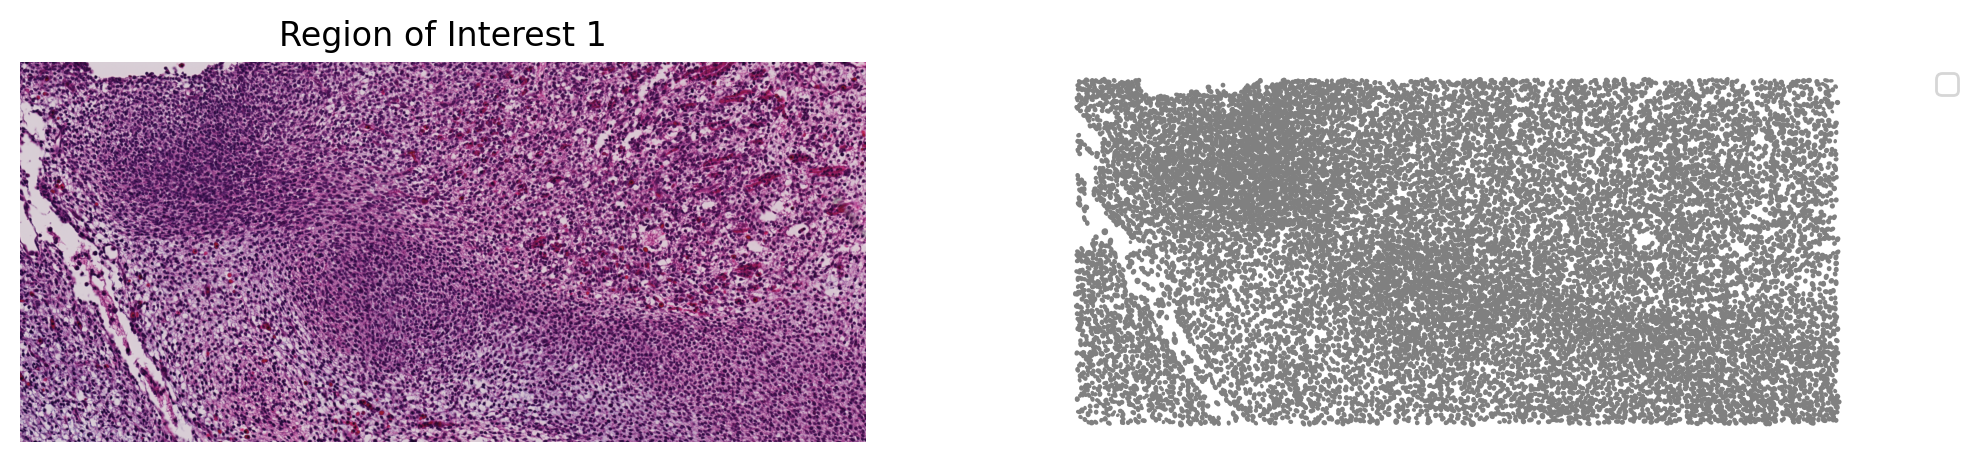

In [12]:
cmap=ListedColormap(['grey'])
bbox_1 =(4193,15924, 13270,20011) #embryo head
#bbox_1 = (8657,17049,12535,21776) # EOM_A1
#bbox_1 = (10787,22811,23326,28170) #EOM_D1

plot_mask_and_save_image(title="Region of Interest 1",gdf=gdf,bbox=bbox_1,cmap=cmap,img=img, buffer=15)

geodataframe.py (1981): 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
3395583233.py (30): No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


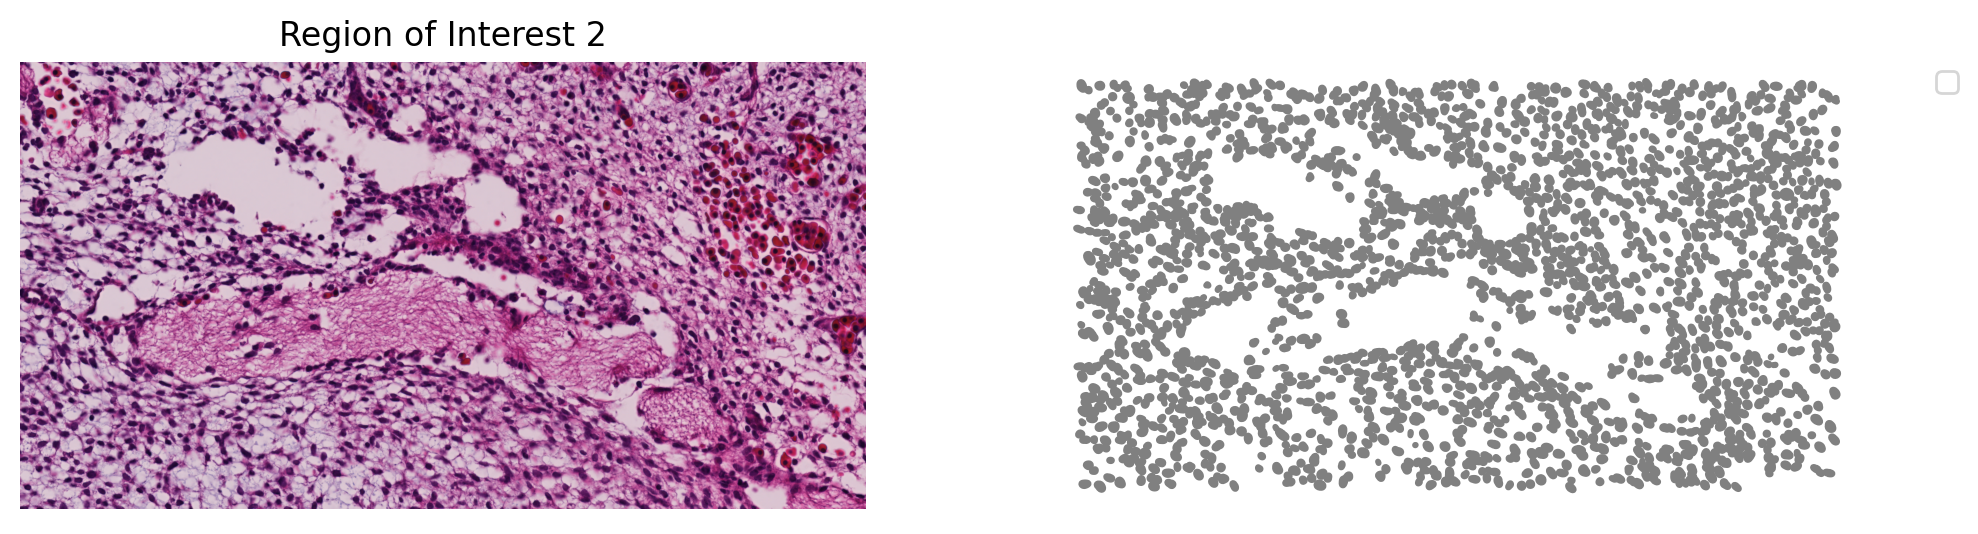

In [13]:
#ROI_2
bbox_2=(11465,29937,16083,32379) #embryo head
#bbox_2=(24697,7860,28044,12958) # EOM_A1
#bbox_2 = (20372,11233,24254,14497) #EOM_D1

plot_mask_and_save_image(title="Region of Interest 2",gdf=gdf,bbox=bbox_2,cmap=cmap,img=img, buffer=15)

geodataframe.py (1981): 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
3395583233.py (30): No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


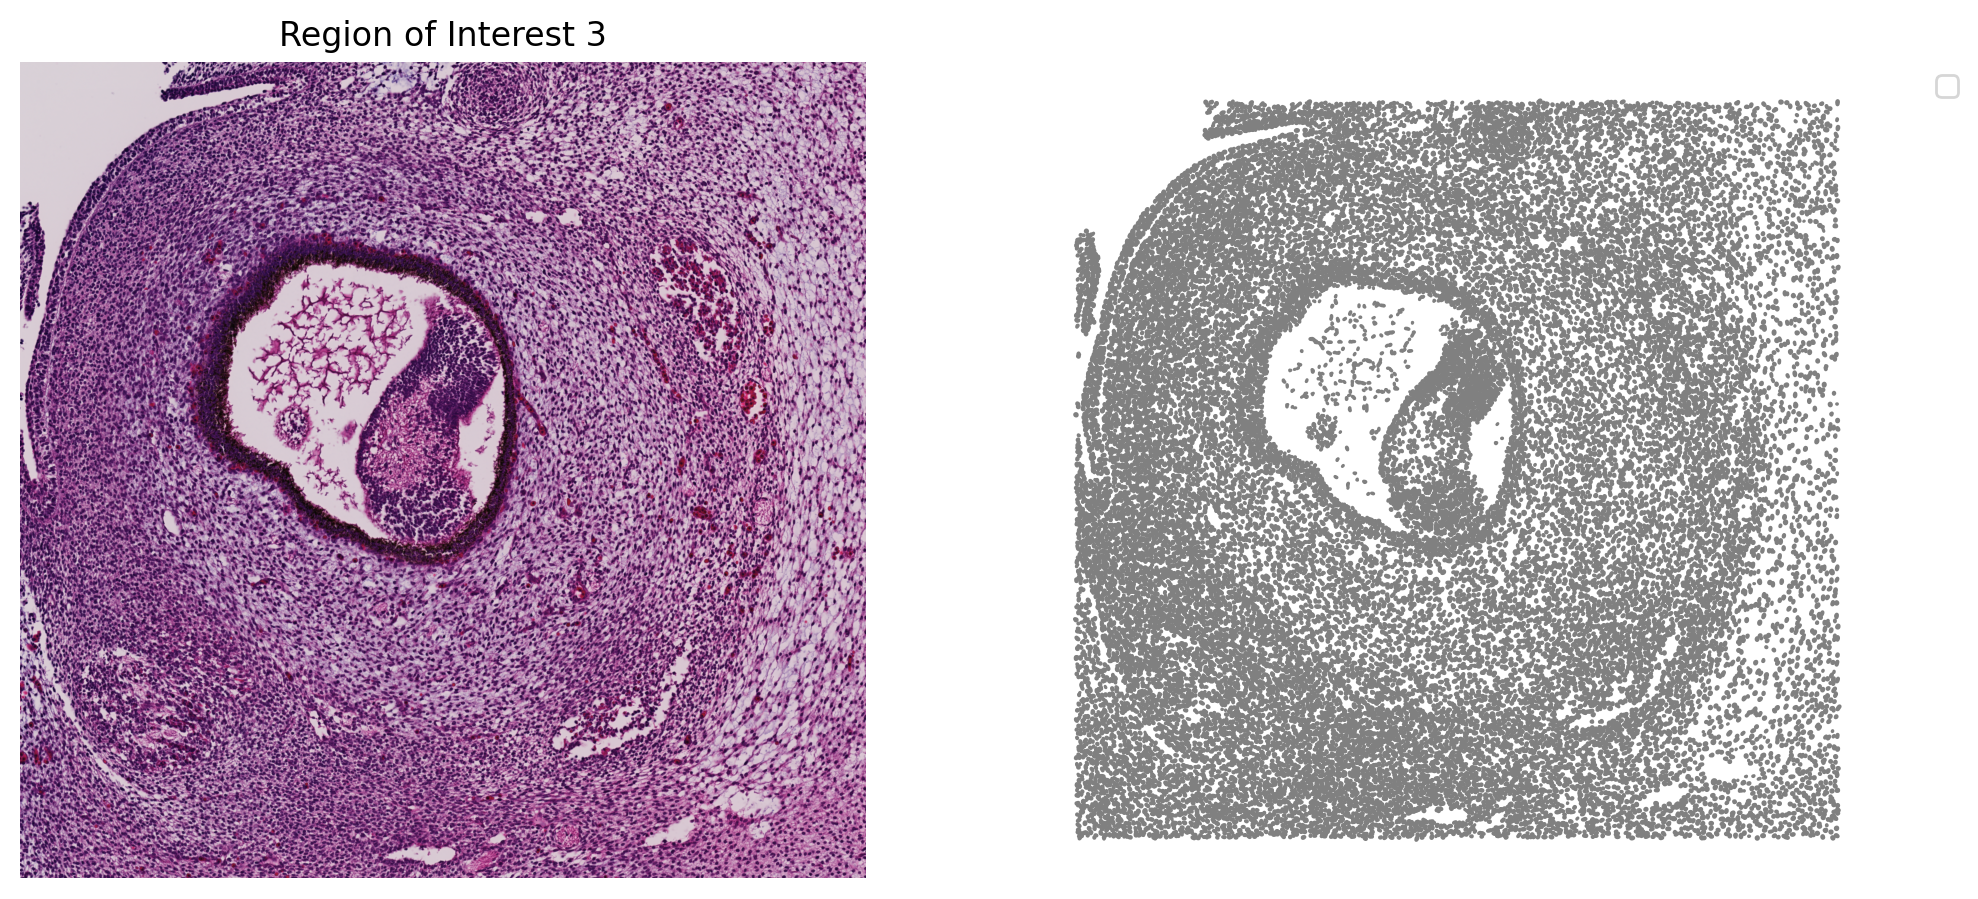

In [15]:
#ROI_3
bbox_3=(3769,21285,13058,30255) # embryo head
#bbox_3 = (29051,11154,32398,15985) #EOM_A1
#bbox_3 = (28239,12813,30816,17898) #EOM_D1

plot_mask_and_save_image(title="Region of Interest 3",gdf=gdf,bbox=bbox_3,cmap=cmap,output_name = 'mask_poster.png', img=img, buffer=15)

#### **Load Visium HD data: genes levels of expression and spatial barcodes + positions**

**Merge the gene expression matrix (rows=bins defined by their barcode and columns=genes) with the spatial information of the bins (in tissue or not & pixels i.e. positions)**

This merging is done thanks to the common element between gene expression matrix and tissue positions: the barcodes of the bins

In [17]:
raw_h5_file = dir_base_exp+'filtered_feature_bc_matrix.h5'
adata = sc.read_10x_h5(raw_h5_file)
adata.var_names_make_unique()

# Load the Spatial Coordinates
tissue_position_file = dir_base_exp+'spatial/tissue_positions.parquet'
df_tissue_positions=pd.read_parquet(tissue_position_file)

#Set the index of the dataframe to the barcodes
df_tissue_positions = df_tissue_positions.set_index('barcode')

# Create an index in the dataframe to check joins
df_tissue_positions['index']=df_tissue_positions.index

# Adding the tissue positions to the meta data
adata.obs =  pd.merge(adata.obs, df_tissue_positions, left_index=True, right_index=True)

# Create a GeoDataFrame from the DataFrame of coordinates
geometry = [Point(xy) for xy in zip(df_tissue_positions['pxl_col_in_fullres'], df_tissue_positions['pxl_row_in_fullres'])]
gdf_coordinates = gpd.GeoDataFrame(df_tissue_positions, geometry=geometry)

anndata.py (1758): Variable names are not unique. To make them unique, call `.var_names_make_unique`.
anndata.py (1758): Variable names are not unique. To make them unique, call `.var_names_make_unique`.


Keep only barcodes falling in nuclei and remove overlapping nuclei

In [18]:
# Perform a spatial join to check which coordinates are in a predicted nucleus
# (knowing that gdf contains the coordinates of the precited nuclei and that gdf_coordinates contain the spatial info of the bins as above)
result_spatial_join = gpd.sjoin(gdf_coordinates, gdf, how='left', predicate='within')

# Identify nuclei associated barcodes and find barcodes that are in more than one nucleus
result_spatial_join['is_within_polygon'] = ~result_spatial_join['index_right'].isna()
barcodes_in_overlaping_polygons = pd.unique(result_spatial_join[result_spatial_join.duplicated(subset=['index'])]['index'])
result_spatial_join['is_not_in_an_polygon_overlap'] = ~result_spatial_join['index'].isin(barcodes_in_overlaping_polygons)

# Remove barcodes in overlapping nuclei
barcodes_in_one_polygon = result_spatial_join[result_spatial_join['is_within_polygon'] & result_spatial_join['is_not_in_an_polygon_overlap']]

# The AnnData object is filtered to only contain the barcodes that are in non-overlapping polygon regions
filtered_obs_mask = adata.obs_names.isin(barcodes_in_one_polygon['index'])
filtered_adata = adata[filtered_obs_mask,:]

# Add the results of the point spatial join to the Anndata object
filtered_adata.obs =  pd.merge(filtered_adata.obs, barcodes_in_one_polygon[['index','geometry','id','is_within_polygon','is_not_in_an_polygon_overlap']], left_index=True, right_index=True)


2852387774.py (3): CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: None
Right CRS: EPSG:3857



In [19]:
# So filtered_adata only contain the expression data of bins that are found in a nuclei, for non overlapping nuclei
filtered_adata.obs 

,in_tissue,array_row,array_col,pxl_row_in_fullres,pxl_col_in_fullres,index_x,index_y,geometry,id,is_within_polygon,is_not_in_an_polygon_overlap
s_002um_01882_01791-1,1,1882,1791,12672.091196,21797.485324,s_002um_01882_01791-1,s_002um_01882_01791-1,POINT (21797.485 12672.091),ID_27633,True,True
s_002um_02767_00643-1,1,2767,643,2519.319640,8533.123161,s_002um_02767_00643-1,s_002um_02767_00643-1,POINT (8533.123 2519.32),ID_1287,True,True
s_002um_02561_00820-1,1,2561,820,4886.145689,10580.974842,s_002um_02561_00820-1,s_002um_02561_00820-1,POINT (10580.975 4886.146),ID_8154,True,True
s_002um_01538_00640-1,1,1538,640,16681.885500,8547.119296,s_002um_01538_00640-1,s_002um_01538_00640-1,POINT (8547.119 16681.885),ID_33572,True,True
s_002um_00727_01427-1,1,727,1427,25996.171864,17648.301593,s_002um_00727_01427-1,s_002um_00727_01427-1,POINT (17648.302 25996.172),ID_61599,True,True
...,...,...,...,...,...,...,...,...,...,...,...
s_002um_01245_00867-1,1,1245,867,20049.240358,11174.566950,s_002um_01245_00867-1,s_002um_01245_00867-1,POINT (11174.567 20049.24),ID_43886,True,True
s_002um_00447_01079-1,1,447,1079,29236.453762,13649.090754,s_002um_00447_01079-1,s_002um_00447_01079-1,POINT (13649.091 29236.454),ID_60381,True,True
s_002um_01703_01021-1,1,1703,1021,14765.392857,12931.138246,s_002um_01703_01021-1,s_002um_01703_01021-1,POINT (12931.138 14765.393),ID_24903,True,True
s_002um_01628_01036-1,1,1628,1036,15629.060072,13106.955537,s_002um_01628_01036-1,s_002um_01628_01036-1,POINT (13106.956 15629.06),ID_35637,True,True


In [20]:
# Group the data by unique nucleous IDs
groupby_object = filtered_adata.obs.groupby(['id'], observed=True)

# Extract the gene expression counts from the AnnData object
counts = filtered_adata.X

# Obtain the number of unique nuclei and the number of genes in the expression data
N_groups = groupby_object.ngroups
N_genes = counts.shape[1]

# Initialize a sparse matrix to store the summed gene counts for each nucleus
summed_counts = sparse.lil_matrix((N_groups, N_genes))

# Lists to store the IDs of polygons and the current row index
polygon_id = []
row = 0

# Iterate over each unique polygon to calculate the sum of gene counts.
for polygons, idx_ in groupby_object.indices.items():
    summed_counts[row] = counts[idx_].sum(0)
    row += 1
    polygon_id.append(polygons)

# Create an AnnData object from the summed count matrix
summed_counts = summed_counts.tocsr()
grouped_filtered_adata = anndata.AnnData(X=summed_counts,obs=pd.DataFrame(polygon_id,columns=['id'],index=polygon_id),var=filtered_adata.var)

%store grouped_filtered_adata


Stored 'grouped_filtered_adata' (AnnData)


### **Quality control of nuclei segmentation results**

OPTIONAL

Study the nuclei area -> remove nuclei that are too large and that most probably correspond to nuclei aggregates or image artifacts. Or too small.

Study the number of UMIs per nuclei -> remove nuclei having too few number of UMIs because they probably won't be useful for clustering

In [21]:
# Parameters to be set for visualization (final parameters for filtering are defined below)
nuclei_area_cutoff = 1300
umi_cutoff = 150

In [22]:
# Store the area of each nucleus in the GeoDataframe containing the nuclei info
gdf['area'] = gdf['geometry'].area

# Add a "mt" column to our spatial gene expression data for mitochondrial genes
grouped_filtered_adata.var["mt"] = grouped_filtered_adata.var_names.str.startswith("MT-")

# Add to the spatial gene expression data some QC metrics, including metrics related to mitochondrial genes as in standard scRNAseq
sc.pp.calculate_qc_metrics(grouped_filtered_adata, qc_vars=["mt"], inplace=True)

grouped_filtered_adata.obs



,id,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,log1p_total_counts_mt,pct_counts_mt
ID_1,ID_1,163,5.099866,174.0,5.164786,35.057471,63.793103,100.000000,100.0,4.0,1.609438,2.298851
ID_10,ID_10,87,4.477337,90.0,4.510860,58.888889,100.000000,100.000000,100.0,3.0,1.386294,3.333333
ID_100,ID_100,167,5.123964,176.0,5.176150,33.522727,61.931818,100.000000,100.0,8.0,2.197225,4.545455
ID_1000,ID_1000,90,4.510860,92.0,4.532599,56.521739,100.000000,100.000000,100.0,2.0,1.098612,2.173913
ID_10000,ID_10000,371,5.918894,388.0,5.963579,17.268041,30.154639,55.927835,100.0,1.0,0.693147,0.257732
...,...,...,...,...,...,...,...,...,...,...,...,...
ID_9995,ID_9995,196,5.283204,212.0,5.361292,31.132075,54.716981,100.000000,100.0,20.0,3.044522,9.433962
ID_9996,ID_9996,144,4.976734,153.0,5.036953,38.562092,71.241830,100.000000,100.0,2.0,1.098612,1.307190
ID_9997,ID_9997,74,4.317488,94.0,4.553877,74.468085,100.000000,100.000000,100.0,2.0,1.098612,2.127660
ID_9998,ID_9998,395,5.981414,422.0,6.047372,18.246445,30.094787,53.791469,100.0,6.0,1.945910,1.421801


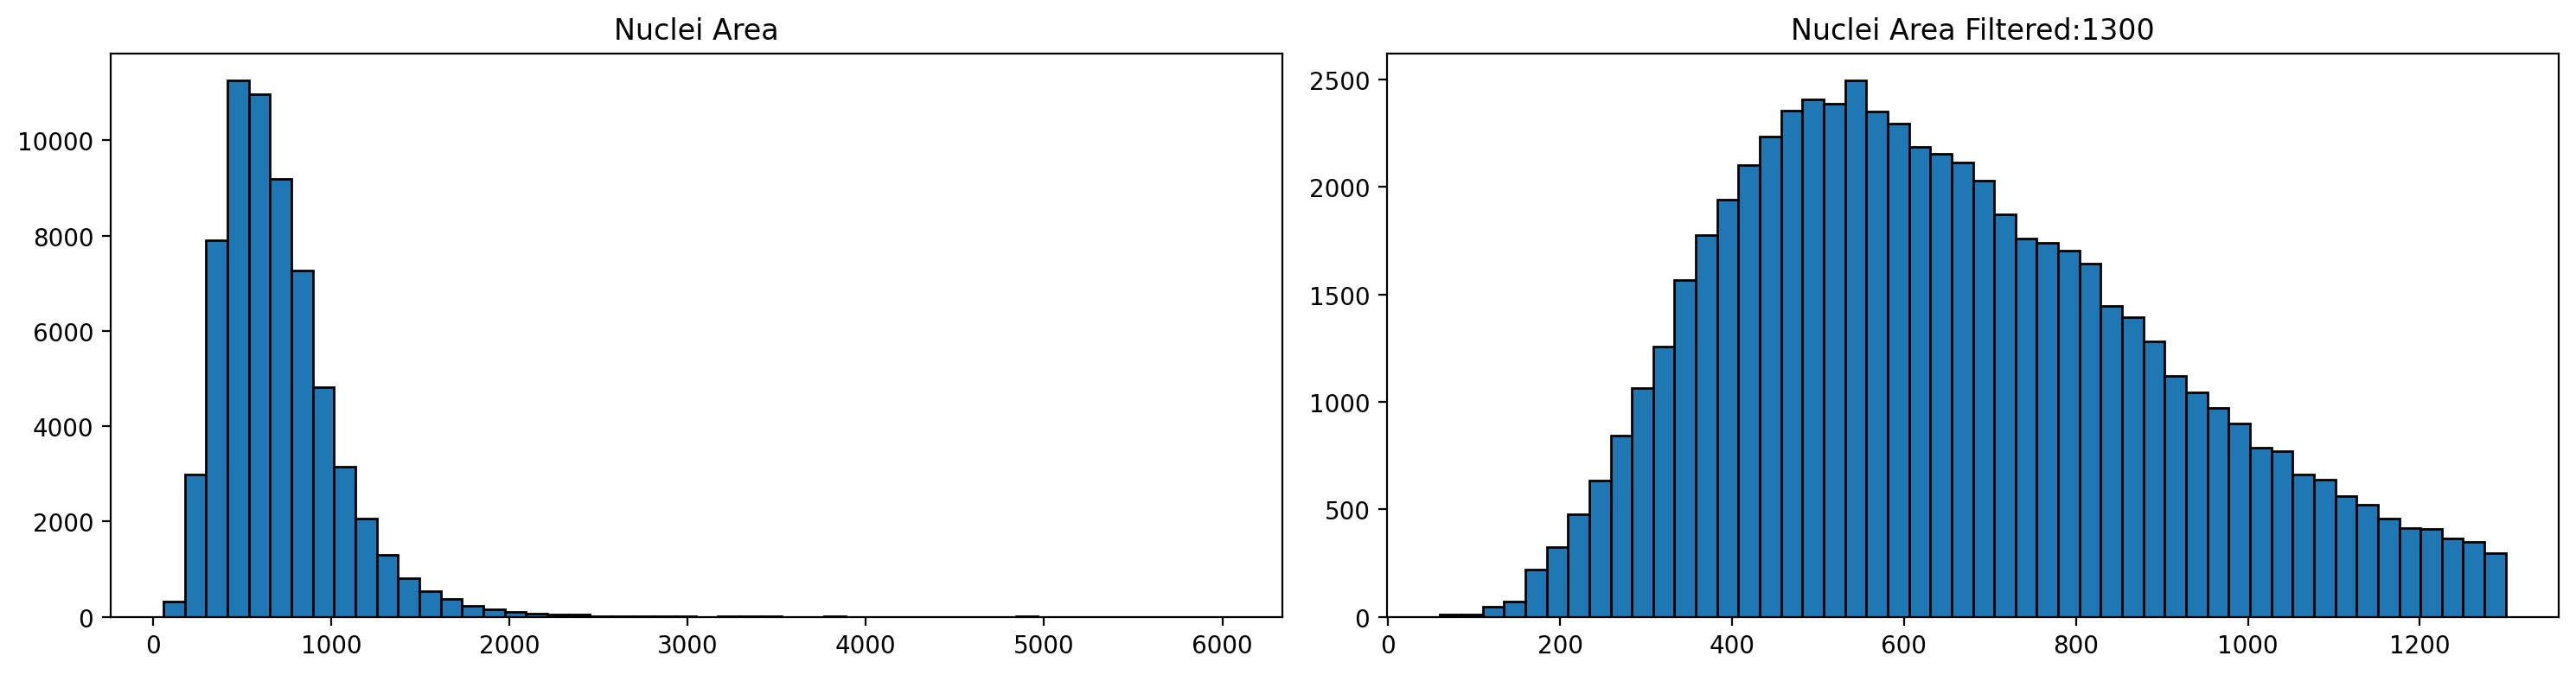

In [23]:
# Plot the nuclei area distribution before (left) and after (right) filtering
plot_nuclei_area(gdf=gdf,area_cut_off=nuclei_area_cutoff)

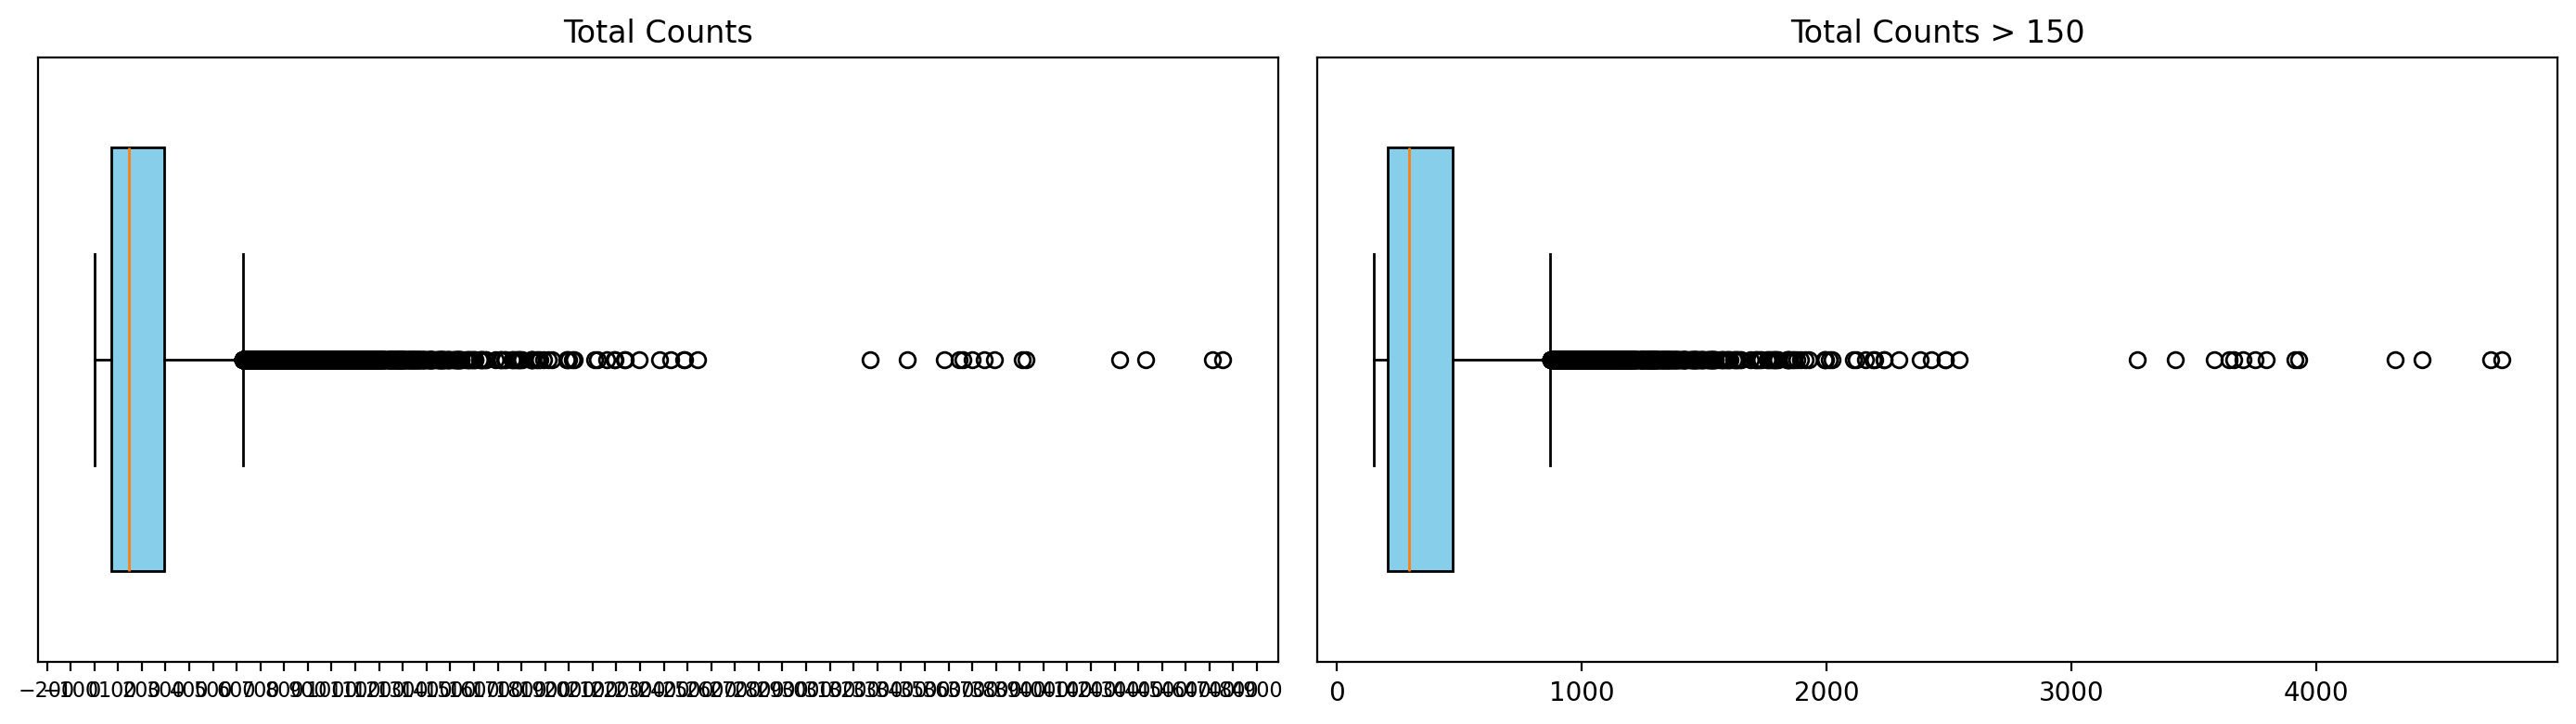

In [24]:
# Plot total UMI distribution (i.e. the number of UMI per nucleus) 
total_umi(grouped_filtered_adata, umi_cutoff)

**Filter data based on min number of UMI required and max nuclei area:**

In [25]:
### Final parameters for filtering ###
nuclei_area_cutoff_max = 1800
nuclei_area_cutoff_min = 100

min_counts_per_gene = 4.5
min_nb_genes_one_count_per_cell = 4.5
max_percent_mito = 5

In [26]:
# Mask to filter based on min and max nuclei area thresholds
mask_area = grouped_filtered_adata.obs['id'].isin(gdf[gdf['area'] < nuclei_area_cutoff_max].id)
mask_area = grouped_filtered_adata.obs['id'].isin(gdf[gdf['area'] > nuclei_area_cutoff_min].id)

anndata.py (1138): Trying to modify attribute `.var` of view, initializing view as actual.
anndata.py (1138): Trying to modify attribute `.var` of view, initializing view as actual.


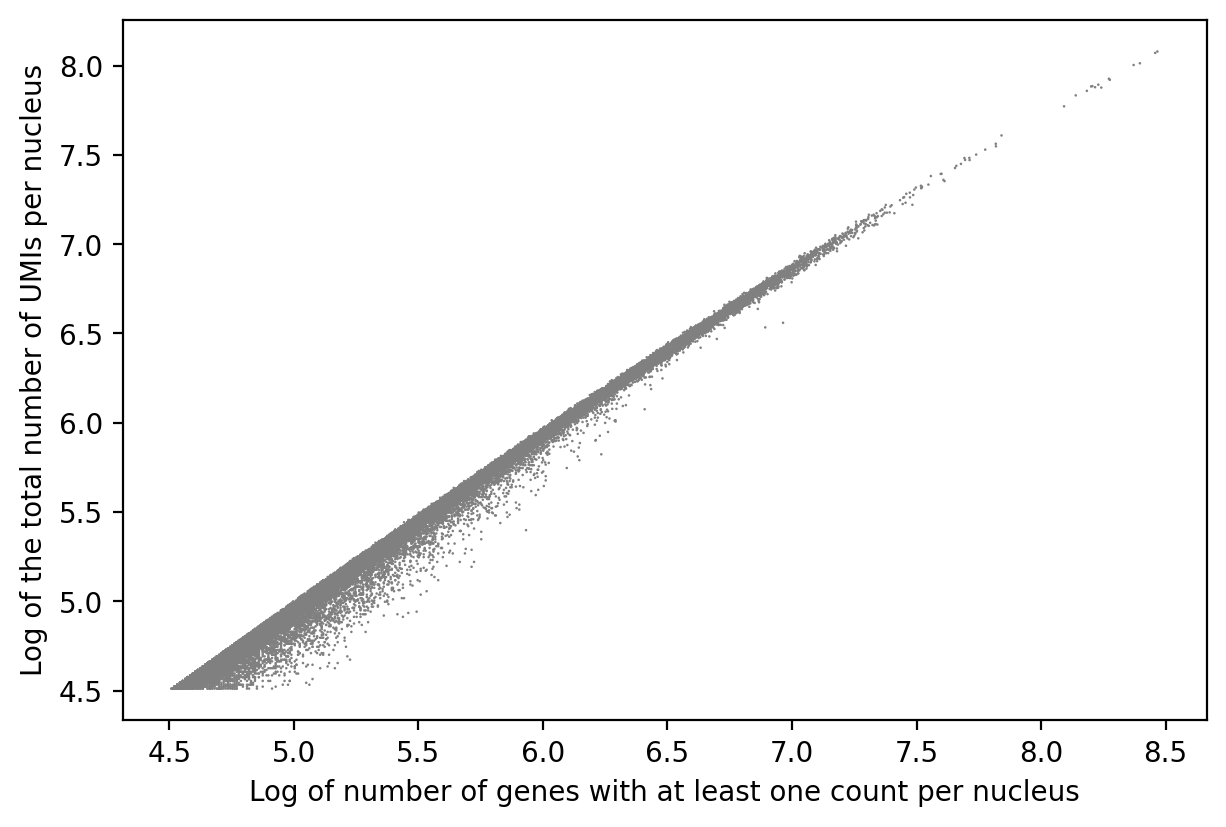

In [27]:
# Mask to filter based on min sum of counts for a gene (=min level of expression per gene)
mask_count = grouped_filtered_adata.obs['log1p_total_counts'] > min_counts_per_gene
# Mask to filter based on min number of genes with at least 1 count in a cell (computed for all cells) (i.e. a cell must have a certain min nb of expressed genes)
mask_gene = grouped_filtered_adata.obs['log1p_n_genes_by_counts'] > min_nb_genes_one_count_per_cell
# Mask to filter based on max percentage of mitochondrial genes 
mask_mt = grouped_filtered_adata.obs['pct_counts_mt'] < max_percent_mito


count_area_filtered_adata = grouped_filtered_adata[mask_area & mask_count & mask_gene & mask_mt, :]
#count_area_filtered_adata = grouped_filtered_adata[grouped_filtered_adata.obs["isOutlier"] == "valid", :]

#sc.pp.calculate_qc_metrics(count_area_filtered_adata, inplace=True)

# In scRNA-seq we expect a positive correlation between nb of UMIs and nb of genes
#fig, ax = plt.subplots(figsize=(6, 6))
ax = sc.pl.scatter(count_area_filtered_adata, x="log1p_total_counts", y="log1p_n_genes_by_counts", show=False)
_ = ax.set_xlabel('Log of number of genes with at least one count per nucleus')
_ = ax.set_ylabel('Log of the total number of UMIs per nucleus')

### **Normalize, highly variable genes, PCA, clustering**

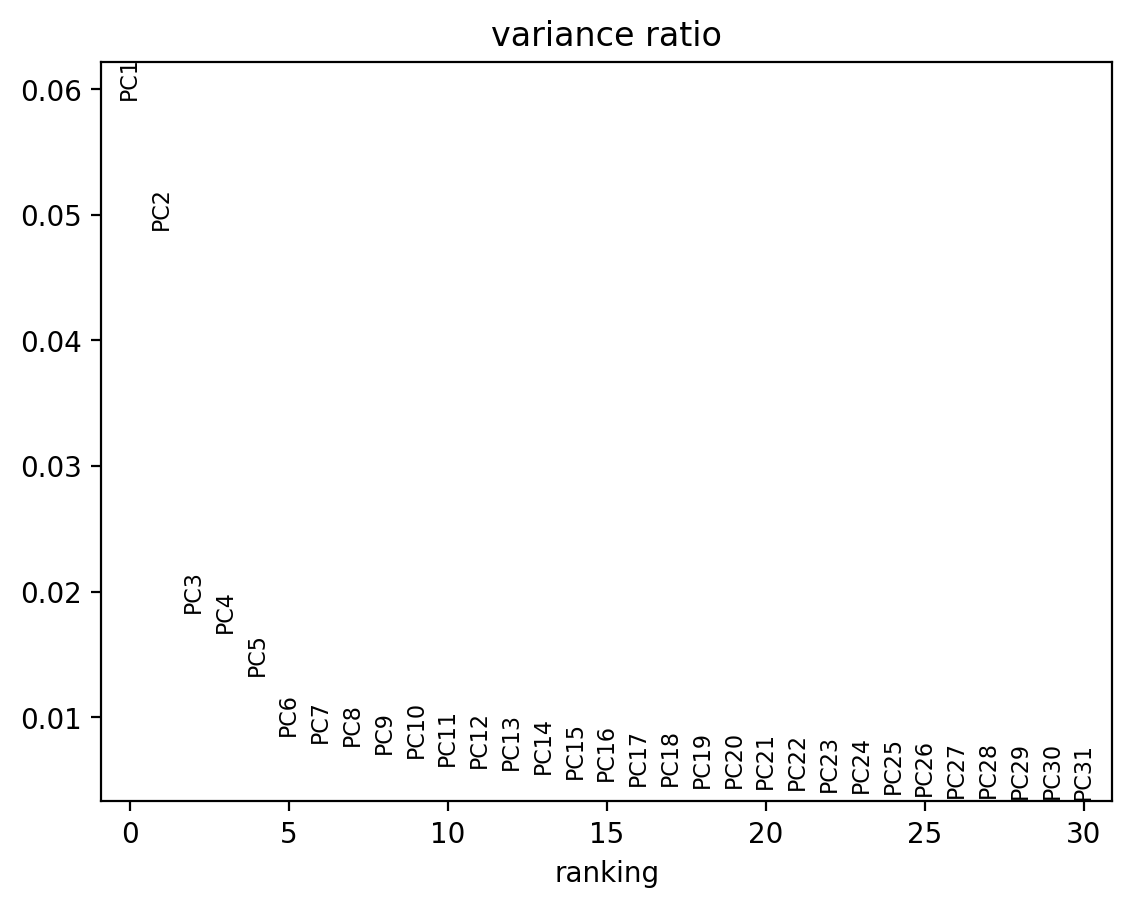

In [28]:
## Save a raw copy of the AnnData object (useful for later DEA for eg)
count_area_filtered_adata.raw = count_area_filtered_adata.copy() 

## This normalized count_area_filtered_adata inplace meaning that the count_area_filtered_adata.X will contain the normalized values
## and thus when I import it and use it in Downstream_analysis_of_segmentation.ipynb I am indeed using the normalized version as desired

# Normalize total counts for each cell in the AnnData object
sc.pp.normalize_total(count_area_filtered_adata, inplace=True)

# Logarithmize the values in the AnnData object after normalization
sc.pp.log1p(count_area_filtered_adata)

# Identify highly variable genes in the dataset using the Seurat method
sc.pp.highly_variable_genes(count_area_filtered_adata, flavor="seurat", n_top_genes=2000)

# Perform Principal Component Analysis (PCA) on the AnnData object
sc.pp.pca(count_area_filtered_adata)
sc.pl.pca_variance_ratio(count_area_filtered_adata)


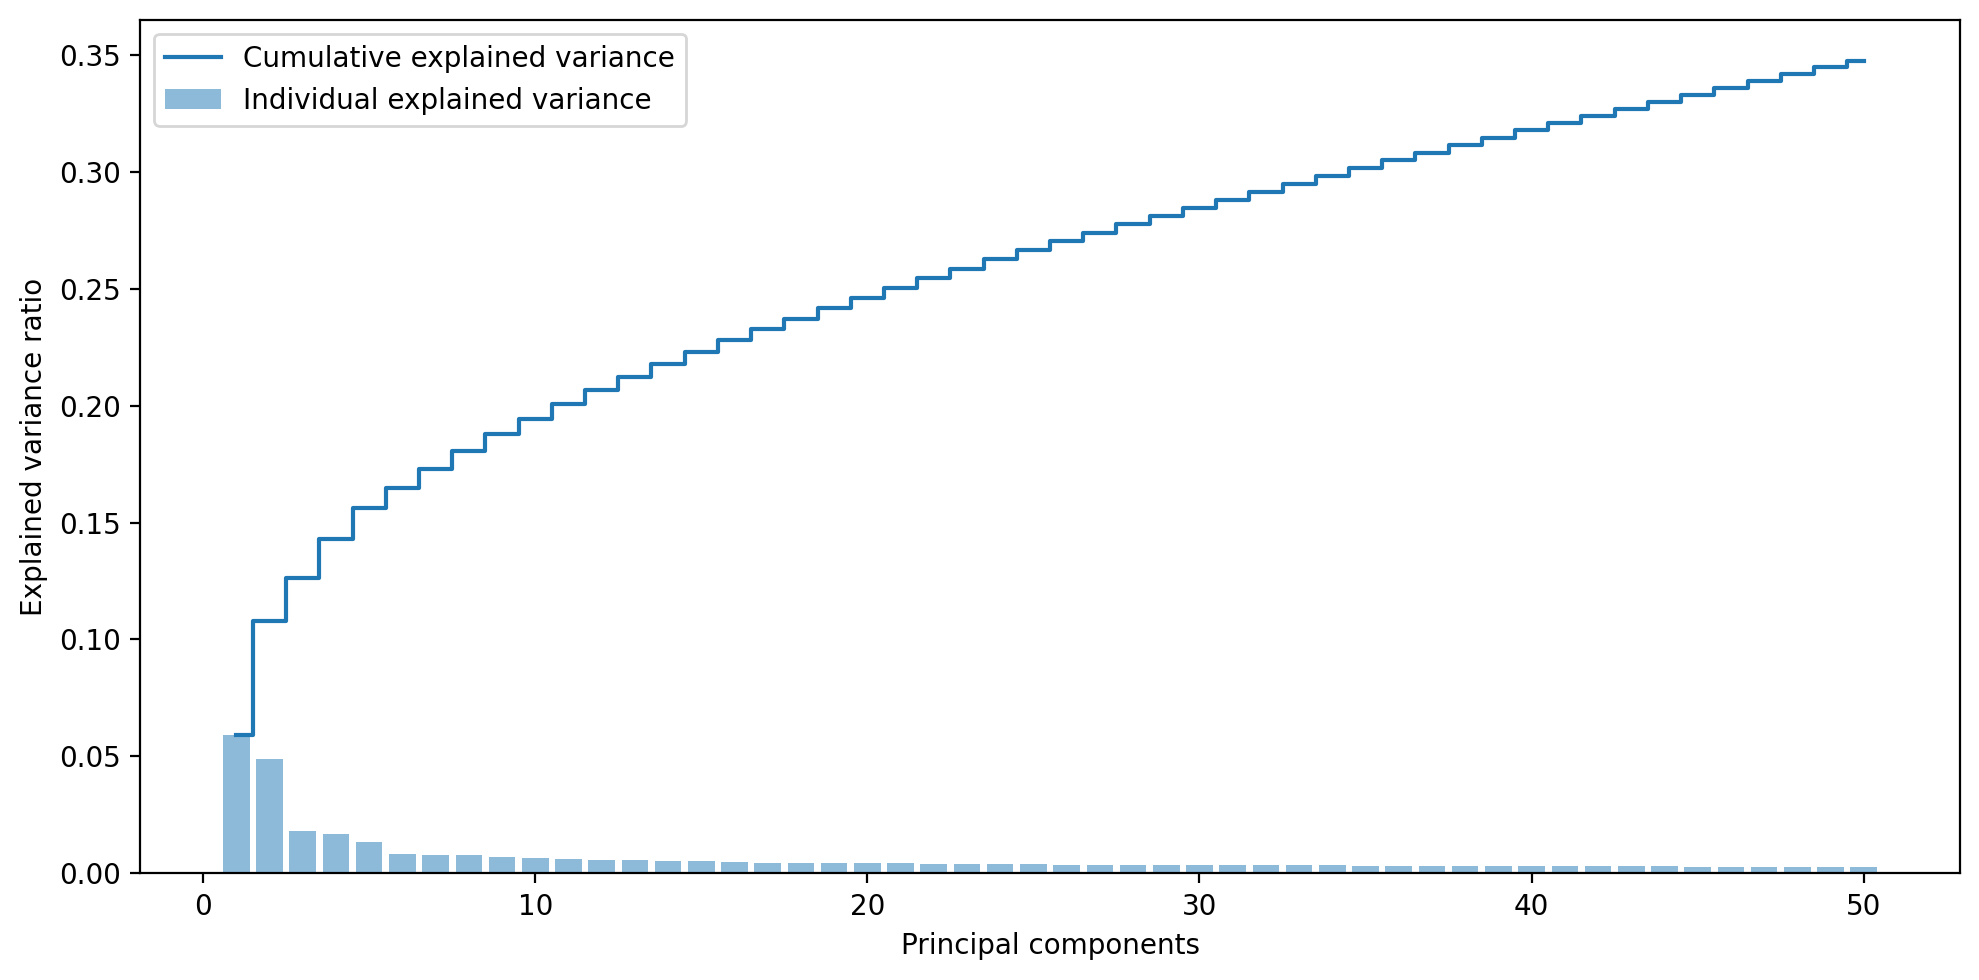

In [29]:
# Or visualize on a scree plot
variance_ratios = count_area_filtered_adata.uns['pca']['variance_ratio']

cumulative_variance = np.cumsum(variance_ratios)

plt.figure(figsize=(10, 5))
plt.bar(range(1, len(variance_ratios) + 1), variance_ratios, alpha=0.5, align='center', label='Individual explained variance')
plt.step(range(1, len(cumulative_variance) + 1), cumulative_variance, where='mid', label='Cumulative explained variance')
plt.ylabel('Explained variance ratio')
plt.xlabel('Principal components')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

In [30]:
## CLUSTERING PARAMETERS, to be fine-tuned
n_pcs = 16
res = 0.3

In [31]:
# Clustering
sc.pp.neighbors(count_area_filtered_adata,  n_pcs=n_pcs)
sc.tl.leiden(count_area_filtered_adata, resolution=res, key_added="clusters")

auto.py (21): IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
2095354104.py (3): In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.


**Save the AnnData object**

In [32]:
count_area_filtered_adata.write_h5ad("./AnnData_Objects/D1_EOM_segmented_object.h5ad")